In [1]:
import re
import os
import ast
import matplotlib
from dataclasses import dataclass, field
from collections import defaultdict
MATCH_PARA = re.compile(r'(\w+)\s+([\d.]+)')
import matplotlib.pyplot as plt
from Utils import *
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import numpy as np
from matplotlib.ticker import FuncFormatter
def format_k(value, tick_number):
    return f"{value / 1000:.1f}k"
formatter = FuncFormatter(format_k)
from matplotlib.ticker import FixedLocator
import math
data_path = "quantum_network_compiler-minimal_codes/FIG_dataset_rebuttal"
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
absolute_path = os.path.join(parent_dir, data_path)
data_path = str(os.path.abspath(absolute_path))
data_path_to_execute = data_path + '/cache_size'
data_path_list = [data_path+'/cache_size', data_path+'/schedu_depth_test', data_path + '/split_mul']
benchmark = ['xor','qft','grover','rca', 'qaoa']
eval = ['cache_size','schedu_depth','split_mul']
buffer_size = [3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,30,35,40,45,50,55,60]
search_depth = range(1,21)

tick_font = 20
labelpad = 10
normalize = False
label_mapping = {
    "Benchmark-0": "MCT", "Benchmark-0-baseline": "MCT-baseline",
    "Benchmark-1": "QFT", "Benchmark-1-baseline": "QFT-baseline",
    "Benchmark-2": "Grover", "Benchmark-2-baseline": "Grover-baseline",
    "Benchmark-3": "RCA", "Benchmark-3-baseline": "RCA-baseline",
    "Benchmark-4": "QAOA", "Benchmark-4-baseline": "QAOA-baseline"
}
line_width = 3
marker_width = 8

def set_axs_i(axs, i):
    axs[i].spines['top'].set_visible(True)
    axs[i].spines['top'].set_color('black')
    axs[i].spines['top'].set_linewidth(1.5)
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    axs[i].spines['right'].set_visible(True)
    axs[i].spines['right'].set_color('black')
    axs[i].spines['right'].set_linewidth(1.5)
    axs[i].tick_params(left=False, bottom=False) 
    axs[i].set_yticklabels([])                    
    axs[i].set_xticklabels([]) 

def set_ax(ax, idx, x_coor, desired_yticks):
    if idx == 0:  # 上面的子图
        # 设置左、上、右边框
        for spine in ['left', 'top', 'right']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color('black')
            ax.spines[spine].set_linewidth(1.5)
        # 隐藏下边框
        ax.spines['bottom'].set_visible(False)
    if idx == 1:  # 下面的子图
        # 设置左、下、右边框
        for spine in ['left', 'bottom', 'right']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color('black')
            ax.spines[spine].set_linewidth(1.5)
    ax.yaxis.set_major_locator(FixedLocator(desired_yticks))
    ax.xaxis.set_major_locator(FixedLocator(x_coor))
    ax.yaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', labelsize=tick_font) 
    ax.tick_params(axis='y', labelsize=tick_font) 

fig2
[23442.0, 21840.0, 17892.0, 17045.0, 16563.0, 16267.0, 16036.0, 16199.0, 16329.0]
[121773.0, 121729.0, 121728.0, 121728.0, 121728.0, 121728.0, 121728.0, 121728.0, 121728.0]
fig3
[36303.0, 38551.0, 30391.0, 27406.0, 26462.0, 25883.0, 25883.0, 25847.0, 25352.0]
[156213.0, 156213.0, 156213.0, 156213.0, 156213.0, 156213.0, 156213.0, 156213.0, 156213.0]
fig4
[12212.0, 10769.0, 9912.0, 9336.0, 9100.0, 8997.0, 9225.0, 8975.0, 9061.0]
[92259.0, 92259.0, 92259.0, 92259.0, 92259.0, 92259.0, 92259.0, 92259.0, 92259.0]
fig5
20748.0


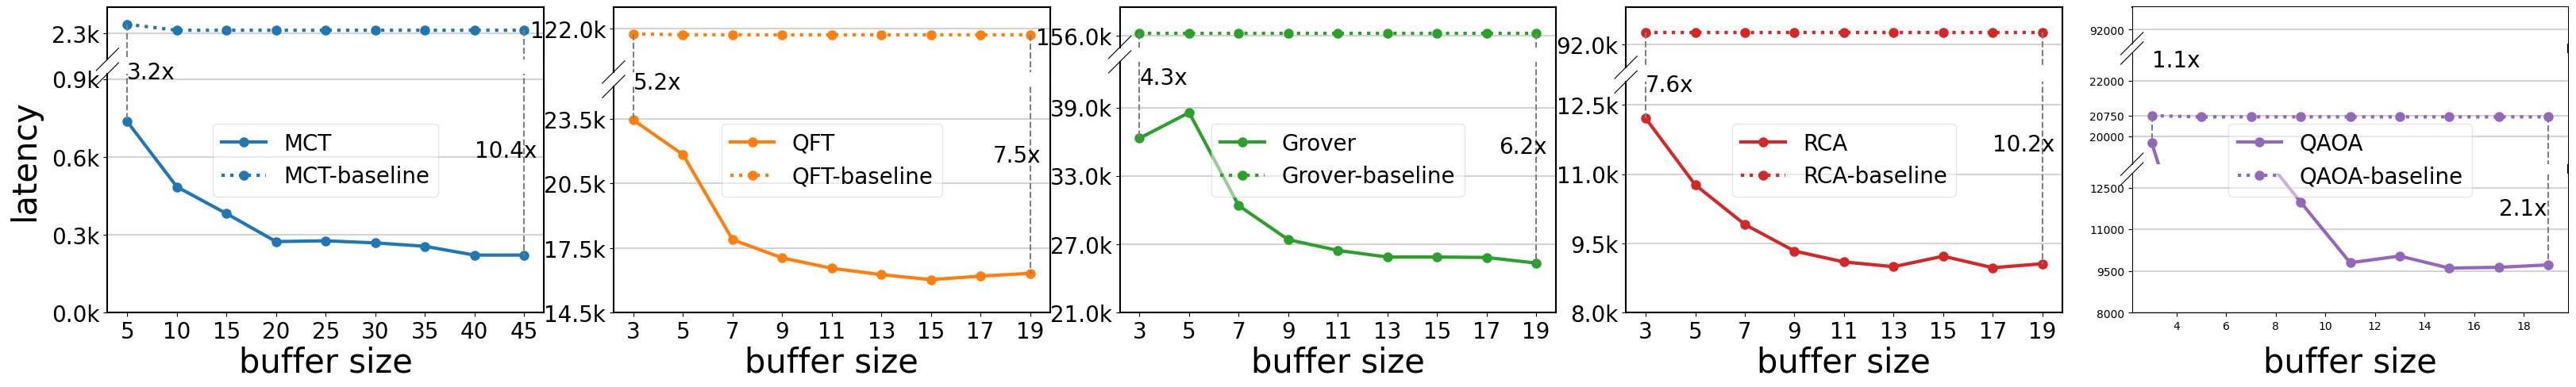

In [5]:
#fig, axs = plt.subplots(1, 4, figsize=(40, 5), gridspec_kw={'wspace': 0.16})
fig, axs = plt.subplots(1, 5, figsize=(40, 5), gridspec_kw={'wspace': 0.16})
diction_our, diction_baseline = compute_dictionaries(data_path_list[0], eval[0], benchmark)
diction_our_const = [a for a in diction_our]
diction_baseline_const = [a for a in diction_baseline]
xlabel = 'buffer size'
ylabel1 = 'latency'
d = 0.005


def set_bax(bax, i):
    bax.plot(x_coor, diction_our[0][i], label=label_mapping[label_key], color=f'C{i}', marker='o', linestyle='-', linewidth=line_width, markersize=marker_width)
    bax.plot(x_coor, diction_baseline[0][i], 
            label=label_mapping[baseline_key], color=f'C{i}', marker='o', linestyle='dotted', linewidth=line_width, markersize=marker_width)
    bax.set_xlabel(xlabel, fontsize=30, color='black',labelpad=30)
    bax.vlines(x_coor[0],ymin = diction_baseline[0][i][0], ymax = diction_our[0][i][0],  colors='gray', linestyles='dashed', linewidth=1.5)
    bax.vlines(x_coor[-1],ymin = diction_baseline[0][i][-1], ymax = diction_our[0][i][-1],  colors='gray', linestyles='dashed', linewidth=1.5)
    bax.legend(fontsize=20, loc='center', framealpha=0.5)
    bax.grid(True, which='both', axis='y', linestyle='-', linewidth=1.5, color='lightgray')



#FIG 8 a1：
i = 0
x_coor = [buffer_size[pp] for pp in [2,7,12,17,22,23,24,25,26]]
diction_our[0][i] = [diction_our_const[0][i][p] for p in [2,7,12,17,22,23,24,25,26]]
diction_baseline[0][i] = [diction_baseline_const[0][i][p] for p in [2,7,12,17,22,23,24,25,26]]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_axs_i(axs, i)
bax = brokenaxes(ylims = ((0,920),(2200,2400)), hspace = 0.1, subplot_spec = ss,fig = fig, d = d)
set_bax(bax, i)
bax.set_ylabel(ylabel1, fontsize=30, color='black', labelpad=60)
bax.vlines(x_coor[-6],ymin = 0, ymax = 2, colors='gray', linestyles='dashed', linewidth=1.5)
desired_yticks = [0,300,600,900,1200,1500,2300]
bax.text(x_coor[0],900,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-5,600,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)



#FIG 8 a2
i = 1
x_coor = [buffer_size[pp] for pp in [0,2,4,6,8,10,12,14,16]]
diction_our[0][i] = [diction_our_const[0][i][p] for p in [0,2,4,6,8,10,12,14,16]]
diction_baseline[0][i] = [diction_baseline_const[0][i][p] for p in [0,2,4,6,8,10,12,14,16]]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[1].get_subplotspec()
set_axs_i(axs, i)
print('fig2')   
print(diction_our[0][i])     
print(diction_baseline[0][i])          
bax = brokenaxes(ylims=((14500,25000),(120000,123000)), hspace=0.1, subplot_spec=ss, fig=fig, d=d)
set_bax(bax, i)
bax.text(x_coor[0],24900,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-1.5,21500,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
bax.vlines(x_coor[2],ymin = 0, ymax = 1, colors='gray', linestyles='dashed', linewidth=1.5)
desired_yticks = [14500,17500,20500,23500,122000]
for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)


#FIG 8 a3
i = 2
x_coor = [buffer_size[pp] for pp in [0,2,4,6,8,10,12,14,16]]
diction_our[0][i] = [diction_our_const[0][i][p] for p in [0,2,4,6,8,10,12,14,16]]
diction_baseline[0][i] = [diction_baseline_const[0][i][p] for p in [0,2,4,6,8,10,12,14,16]]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_axs_i(axs, i)
print('fig3') 
print(diction_our[0][i])
print(diction_baseline[0][i])                  
bax = brokenaxes(ylims=((21000,43000),(155000,158500)), hspace=0.1, subplot_spec=ss, fig=fig, d=d)
set_bax(bax, i)
bax.vlines(x_coor[3],ymin = 0, ymax = 1, colors='gray', linestyles='dashed', linewidth=1.5)
desired_yticks = [21000,27000,33000,39000,156000]
bax.text(x_coor[0],41000,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-1.5,35000,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)


    
#FIG 8 a4
i = 3
x_coor = [buffer_size[pp] for pp in [0,2,4,6,8,10,12,14,16]]
diction_our[0][i] = [diction_our_const[0][i][p] for p in [0,2,4,6,8,10,12,14,16]]
diction_baseline[0][i] = [diction_baseline_const[0][i][p] for p in [0,2,4,6,8,10,12,14,16]]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_axs_i(axs, i)
print('fig4')   
print(diction_our[0][i])  
print(diction_baseline[0][i])                  
bax = brokenaxes(ylims=((8000,13000),(91500,92800)), hspace=0.1, subplot_spec=ss, fig=fig, d=d)
set_bax(bax, i)
desired_yticks = [8000,9500,11000,12500,92000]
bax.text(x_coor[0],12800,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-2,11500,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)


#FIG 8 a5
i = 4
x_coor = [buffer_size[pp] for pp in [0,2,4,6,8,10,12,14,16]]
diction_our[0][i] = [diction_our_const[0][i][p] for p in [0,2,4,6,8,10,12,14,16]]
diction_baseline[0][i] = [diction_baseline_const[0][i][p] for p in [0,2,4,6,8,10,12,14,16]]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_axs_i(axs, i)
print('fig5')
# bax = brokenaxes(ylims=((8000,13000),(91500,92800)), hspace=0.1, subplot_spec=ss, fig=fig, d=d)
# set_bax(bax, i)
# desired_yticks = [8000,9500,11000,12500,92000]
# print(diction_baseline[0][i][0])
# bax.text(x_coor[0],12800,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
# bax.text(x_coor[-1]-2,11500,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
# for idx, ax in enumerate(bax.axs):
#     set_ax(ax, idx, x_coor, desired_yticks)

bax = brokenaxes(
    ylims=((8000, 13000), (19000, 23000), (91500, 92800)),
    hspace=0.1,
    subplot_spec=ss,
    fig=fig,
    d=d
)

set_bax(bax, i)

# segment-aware yticks (ONLY change is adding middle-range ticks)
desired_yticks = [
    8000, 9500, 11000, 12500,      # lower segment
    20000, 20750, 22000,           # middle segment (contains 20748)
    92000                          # upper segment
]

print(diction_baseline[0][i][0])

# annotations MUST fall inside a defined segment
bax.text(
    x_coor[0],
    22500,   # inside middle segment
    f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',
    fontsize=20
)

bax.text(
    x_coor[-1] - 2,
    11500,   # inside lower segment
    f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',
    fontsize=20
)

# apply ticks per broken axis
for idx, ax in enumerate(bax.axs):
    ymin, ymax = ax.get_ylim()
    ax.set_yticks([t for t in desired_yticks if ymin <= t <= ymax])

plt.savefig('fig/FIG_8a.pdf', bbox_inches='tight')
plt.show()


In [ ]:
    import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import FixedLocator
fig, axs = plt.subplots(1, 4, figsize=(40, 5))
plt.subplots_adjust(wspace=0.16, hspace=0.2)
diction_our, diction_baseline = compute_dictionaries(data_path_list[1], eval[1], benchmark)
diction_our_const = diction_our
x_coor = [search_depth[i-1] for i in [1,3,5,7,9,11,13,15,17,19]]
xlabel = 'look-ahead depth'
ylabel1 = 'latency'
d = 0.005



def set_bax(bax, i):
    bax.plot(x_coor, diction_our[0][i], label=label_mapping[label_key], color=f'C{i}', marker='o', linestyle='-', linewidth=line_width, markersize=marker_width)
    bax.plot(x_coor, [diction_baseline[0][i][0] for _ in diction_our[0][i]], label=label_mapping[baseline_key], color=f'C{i}', marker='o', linestyle='dotted', linewidth=line_width, markersize=marker_width)
    bax.set_xlabel(xlabel, fontsize=30, color='black',labelpad=30)
    bax.vlines(x_coor[0],ymin = diction_baseline[0][i][0], ymax = diction_our[0][i][0],  colors='gray', linestyles='dashed', linewidth=1.5)
    bax.vlines(x_coor[-1],ymin = diction_baseline[0][i][-1], ymax = diction_our[0][i][-1],  colors='gray', linestyles='dashed', linewidth=1.5)
    bax.legend(fontsize=20, loc='center', framealpha=0.5)
    bax.grid(True, which='both', axis='y', linestyle='-', linewidth=1.5, color='lightgray')


#FIG 8 b1
i = 0
diction_our[0][i] = [diction_our_const[0][i][j-1] for j in [1,3,5,7,9,11,13,15,17,19]]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_axs_i(axs, i)

bax = brokenaxes(ylims = ((300,650),(2290,2340)), hspace = 0.1, subplot_spec = ss,fig = fig, d = d)
set_bax(bax, i)

bax.legend(fontsize=20, loc='lower left', framealpha=0.5)
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
bax.set_ylabel(ylabel1, fontsize=30, color='black', labelpad=60)
bax.text(x_coor[0],630,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-2,530,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
desired_yticks = [300,400,500,600,700,2300]

for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)


#FIG 8 b2
i = 1
x_coor = search_depth[:13]
diction_our[0][i] = diction_our_const[0][i][:13]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_axs_i(axs, i)
bax = brokenaxes(ylims = ((10000,34000),(120000,124000)), hspace = 0.1, subplot_spec = ss,fig = fig, d = d)
set_bax(bax, i)
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
bax.text(x_coor[0],33900,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-1.2,26000,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
desired_yticks = [10000,17000,24000,31000,121000]

for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)


#FIG8 b3
i = 2
diction_our[0][i] = diction_our_const[0][i][:13]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[2].get_subplotspec()
set_axs_i(axs, i)
bax = brokenaxes(ylims = ((10000,78000),(153000,164000)), hspace = 0.1, subplot_spec = ss,fig = fig, d = d)
set_bax(bax, i)
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
desired_yticks = [10000,30000,50000,70000,160000]
bax.text(x_coor[0],76000,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-1.2,53000,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)

for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)

    
i = 3
diction_our[0][i] = diction_our_const[0][i][:13]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_axs_i(axs, i)
bax = brokenaxes(ylims = ((3000,23000),(90000,94500)), hspace = 0.1, subplot_spec = ss,fig = fig, d = d)
set_bax(bax, i)
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
bax.text(x_coor[0],22900,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-1.5,16500,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
desired_yticks = [3000,9000,15000,21000,93000]

for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)


i = 4
diction_our[0][i] = diction_our_const[0][i][:13]
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_axs_i(axs, i)
bax = brokenaxes(ylims = ((3000,23000),(90000,94500)), hspace = 0.1, subplot_spec = ss,fig = fig, d = d)
set_bax(bax, i)
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
bax.text(x_coor[0],22900,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-1.5,16500,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
desired_yticks = [3000,9000,15000,21000,93000]

for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)


plt.savefig('fig/FIG_8b.pdf', bbox_inches='tight')
plt.show()
